# <span style="font-size:16pt; font-weight:bold;">Notebook 22: Comprehensive ML Baselines Comparison</span>


## <span style="font-size:14pt; font-weight:bold;">1. Setup and Loading</span>


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path; import warnings; warnings.filterwarnings('ignore')
REPO=Path.home()/'projects'/'music-prediction'
IMGS=REPO/'results/figures/thesis'; ANALYSIS=REPO/'results/analysis'; MET=REPO/'results/metrics/thesis_ml_test'
IMGS.mkdir(parents=True,exist_ok=True); ANALYSIS.mkdir(parents=True,exist_ok=True)
TARGETS = ['valence', 'energy', 'danceability', 'popularity']
TC = {'valence':'#4C72B0','energy':'#DD8452','danceability':'#55A868','popularity':'#C44E52'}
plt.rcParams.update({'figure.dpi':150,'savefig.dpi':300,'savefig.bbox':'tight','font.size':12,'axes.labelsize':14,'axes.titlesize':14})


In [2]:
# Exclude the placeholder baseline model robustly
DP = MET / 'thesis_ml_results_test_20260528_230741.csv'
TP = MET / 'thesis_ml_results_test_20260601_160912.csv'

if DP.exists() and TP.exists():
    dd = pd.read_csv(DP)
    dt = pd.read_csv(TP)

    dd['tuning'] = 'default'
    dt['tuning'] = 'tuned'

    ml = pd.concat([dd, dt], ignore_index=True)

    # Remove 'Mean' even if there are stray spaces/case issues
    ml = ml[~ml['model'].astype(str).str.strip().eq('Mean')].copy()

    print(f'Loaded {len(dd)} default + {len(dt)} tuned rows')
    print(f"Filtered models: {ml['model'].unique()}")
    print(f"Targets: {ml['target'].unique()}")
else:
    print('Files not found.')
    raise FileNotFoundError()


Loaded 32 default + 4 tuned rows
Filtered models: <StringArray>
[         'Ridge',        'XGBoost',       'LightGBM',       'CatBoost',
   'MLPRegressor',     'ExtraTrees',   'RandomForest', 'CatBoost_tuned']
Length: 8, dtype: str
Targets: <StringArray>
['valence', 'energy', 'danceability', 'popularity']
Length: 4, dtype: str


## <span style="font-size:14pt; font-weight:bold;">2. Overall ML Performance</span>


ML Family R2 (Default)
target        valence  energy  danceability  popularity     Avg
model                                                          
CatBoost       0.7158  0.9187        0.7852      0.1285  0.6371
XGBoost        0.6737  0.9015        0.7489      0.1272  0.6128
LightGBM       0.6713  0.8986        0.7440      0.1286  0.6106
Ridge          0.6669  0.8904        0.7073      0.1003  0.5912
ExtraTrees     0.6381  0.8865        0.7135      0.1116  0.5874
RandomForest   0.6255  0.8828        0.7089      0.1110  0.5821
MLPRegressor   0.6064  0.8604        0.6631      0.0973  0.5568


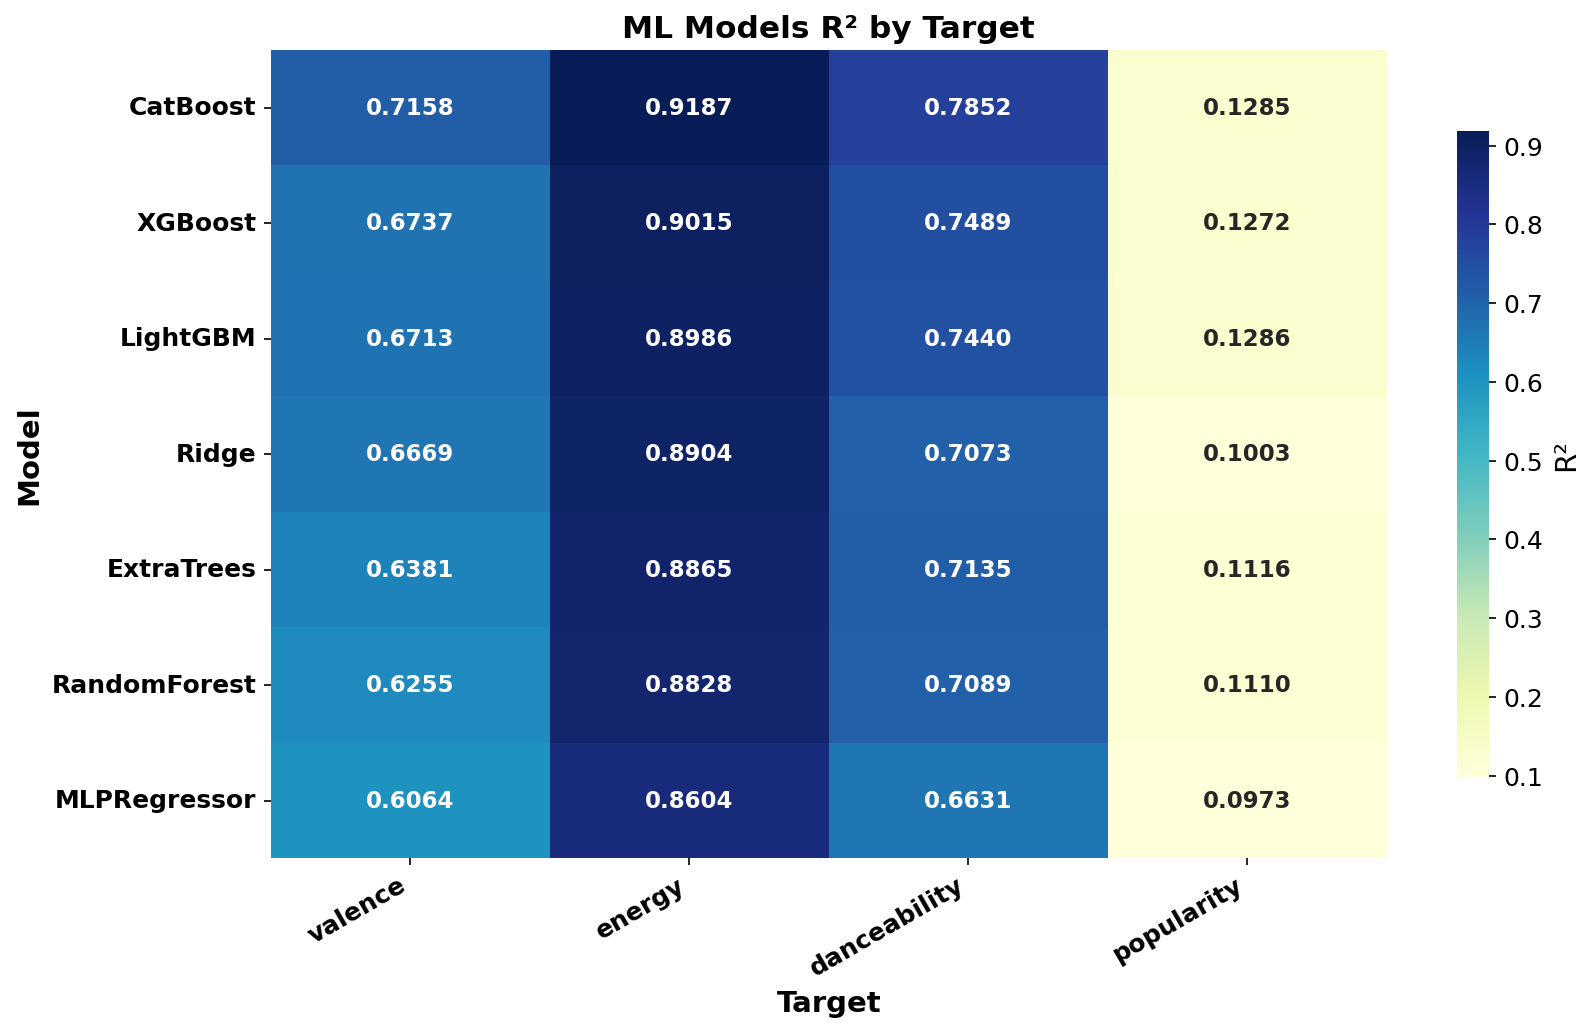

In [3]:
dft = ml[ml['tuning']=='default']
pr = dft.pivot_table(index='model',columns='target',values='r2',aggfunc='first')
pr = pr[TARGETS]; pr['Avg']=pr.mean(axis=1); pr=pr.sort_values('Avg',ascending=False)
print('ML Family R2 (Default)'); print('='*60); print(pr.round(4).to_string())
fig,ax=plt.subplots(figsize=(12,7))
sns.heatmap(pr[TARGETS],annot=True,fmt='.4f',cmap='YlGnBu',cbar_kws={'label':'R²','shrink':0.8},ax=ax,annot_kws={'fontsize':11,'fontweight':'bold'})
ax.set_title('ML Models R² by Target',fontsize=15,fontweight='bold')
ax.set_ylabel('Model',fontsize=14,fontweight='bold'); ax.set_xlabel('Target',fontsize=14,fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(),rotation=30,ha='right',fontsize=12,fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=12,fontweight='bold')
fig.savefig(IMGS/'22_ml_heatmap.png'); plt.show()


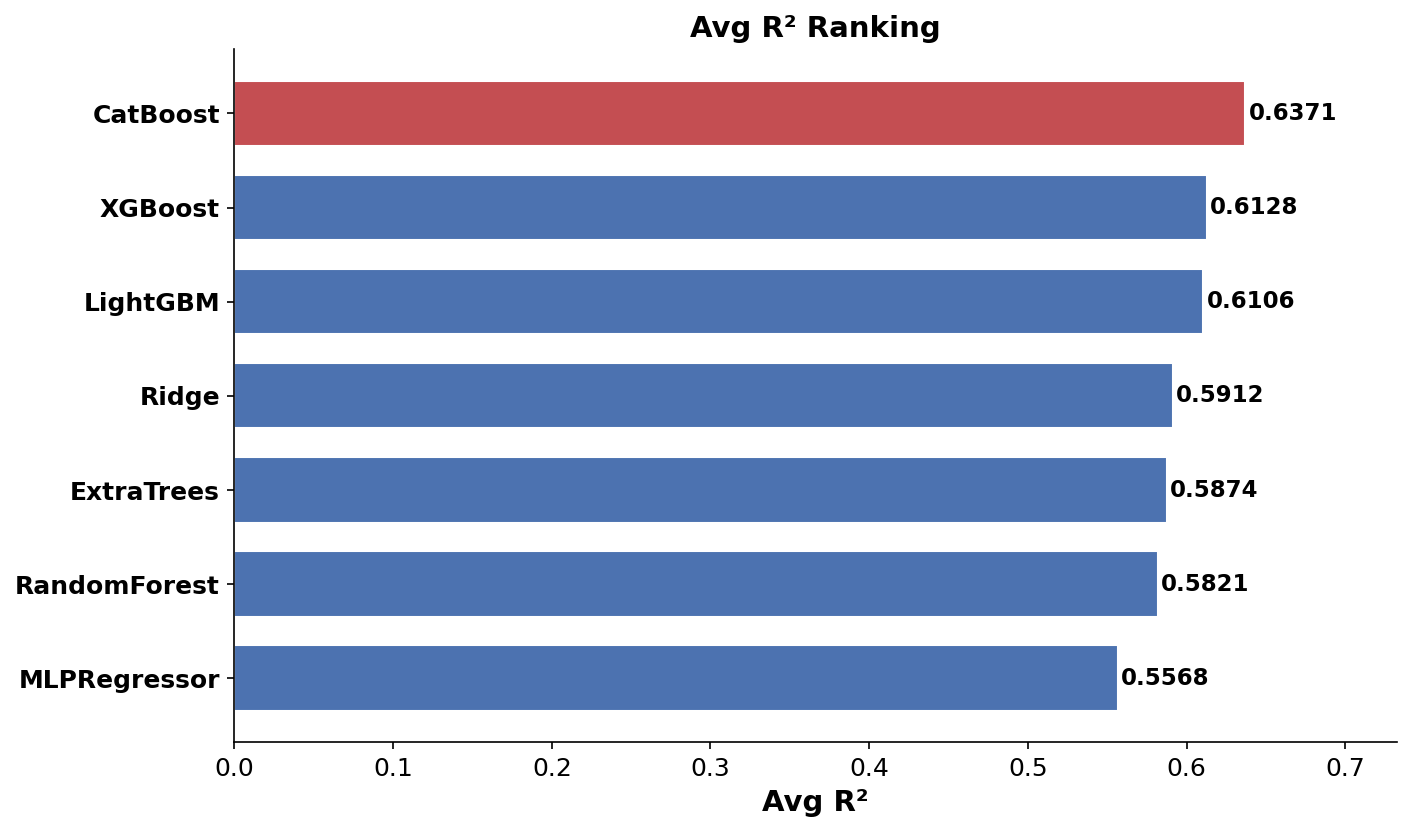

In [4]:
fig,ax=plt.subplots(figsize=(10,6))
av=pr['Avg']; colors=['#C44E52' if 'CatBoost' in n else '#4C72B0' for n in av.index]
bars=ax.barh(range(len(av)),av.values,color=colors,edgecolor='white',height=0.7)
ax.set_yticks(range(len(av))); ax.set_yticklabels(av.index,fontsize=12,fontweight='bold')
ax.set_xlabel('Avg R²',fontsize=14,fontweight='bold'); ax.set_title('Avg R² Ranking',fontsize=14,fontweight='bold')
for b,v in zip(bars,av.values): ax.text(b.get_width()+0.002,b.get_y()+b.get_height()/2,f'{v:.4f}',va='center',fontsize=11,fontweight='bold')
ax.set_xlim(0,max(av.values)*1.15); ax.invert_yaxis(); sns.despine()
fig.savefig(IMGS/'22_ml_avg_r2.png'); plt.show()


## <span style="font-size:14pt; font-weight:bold;">3. Per-Target Top-5</span>


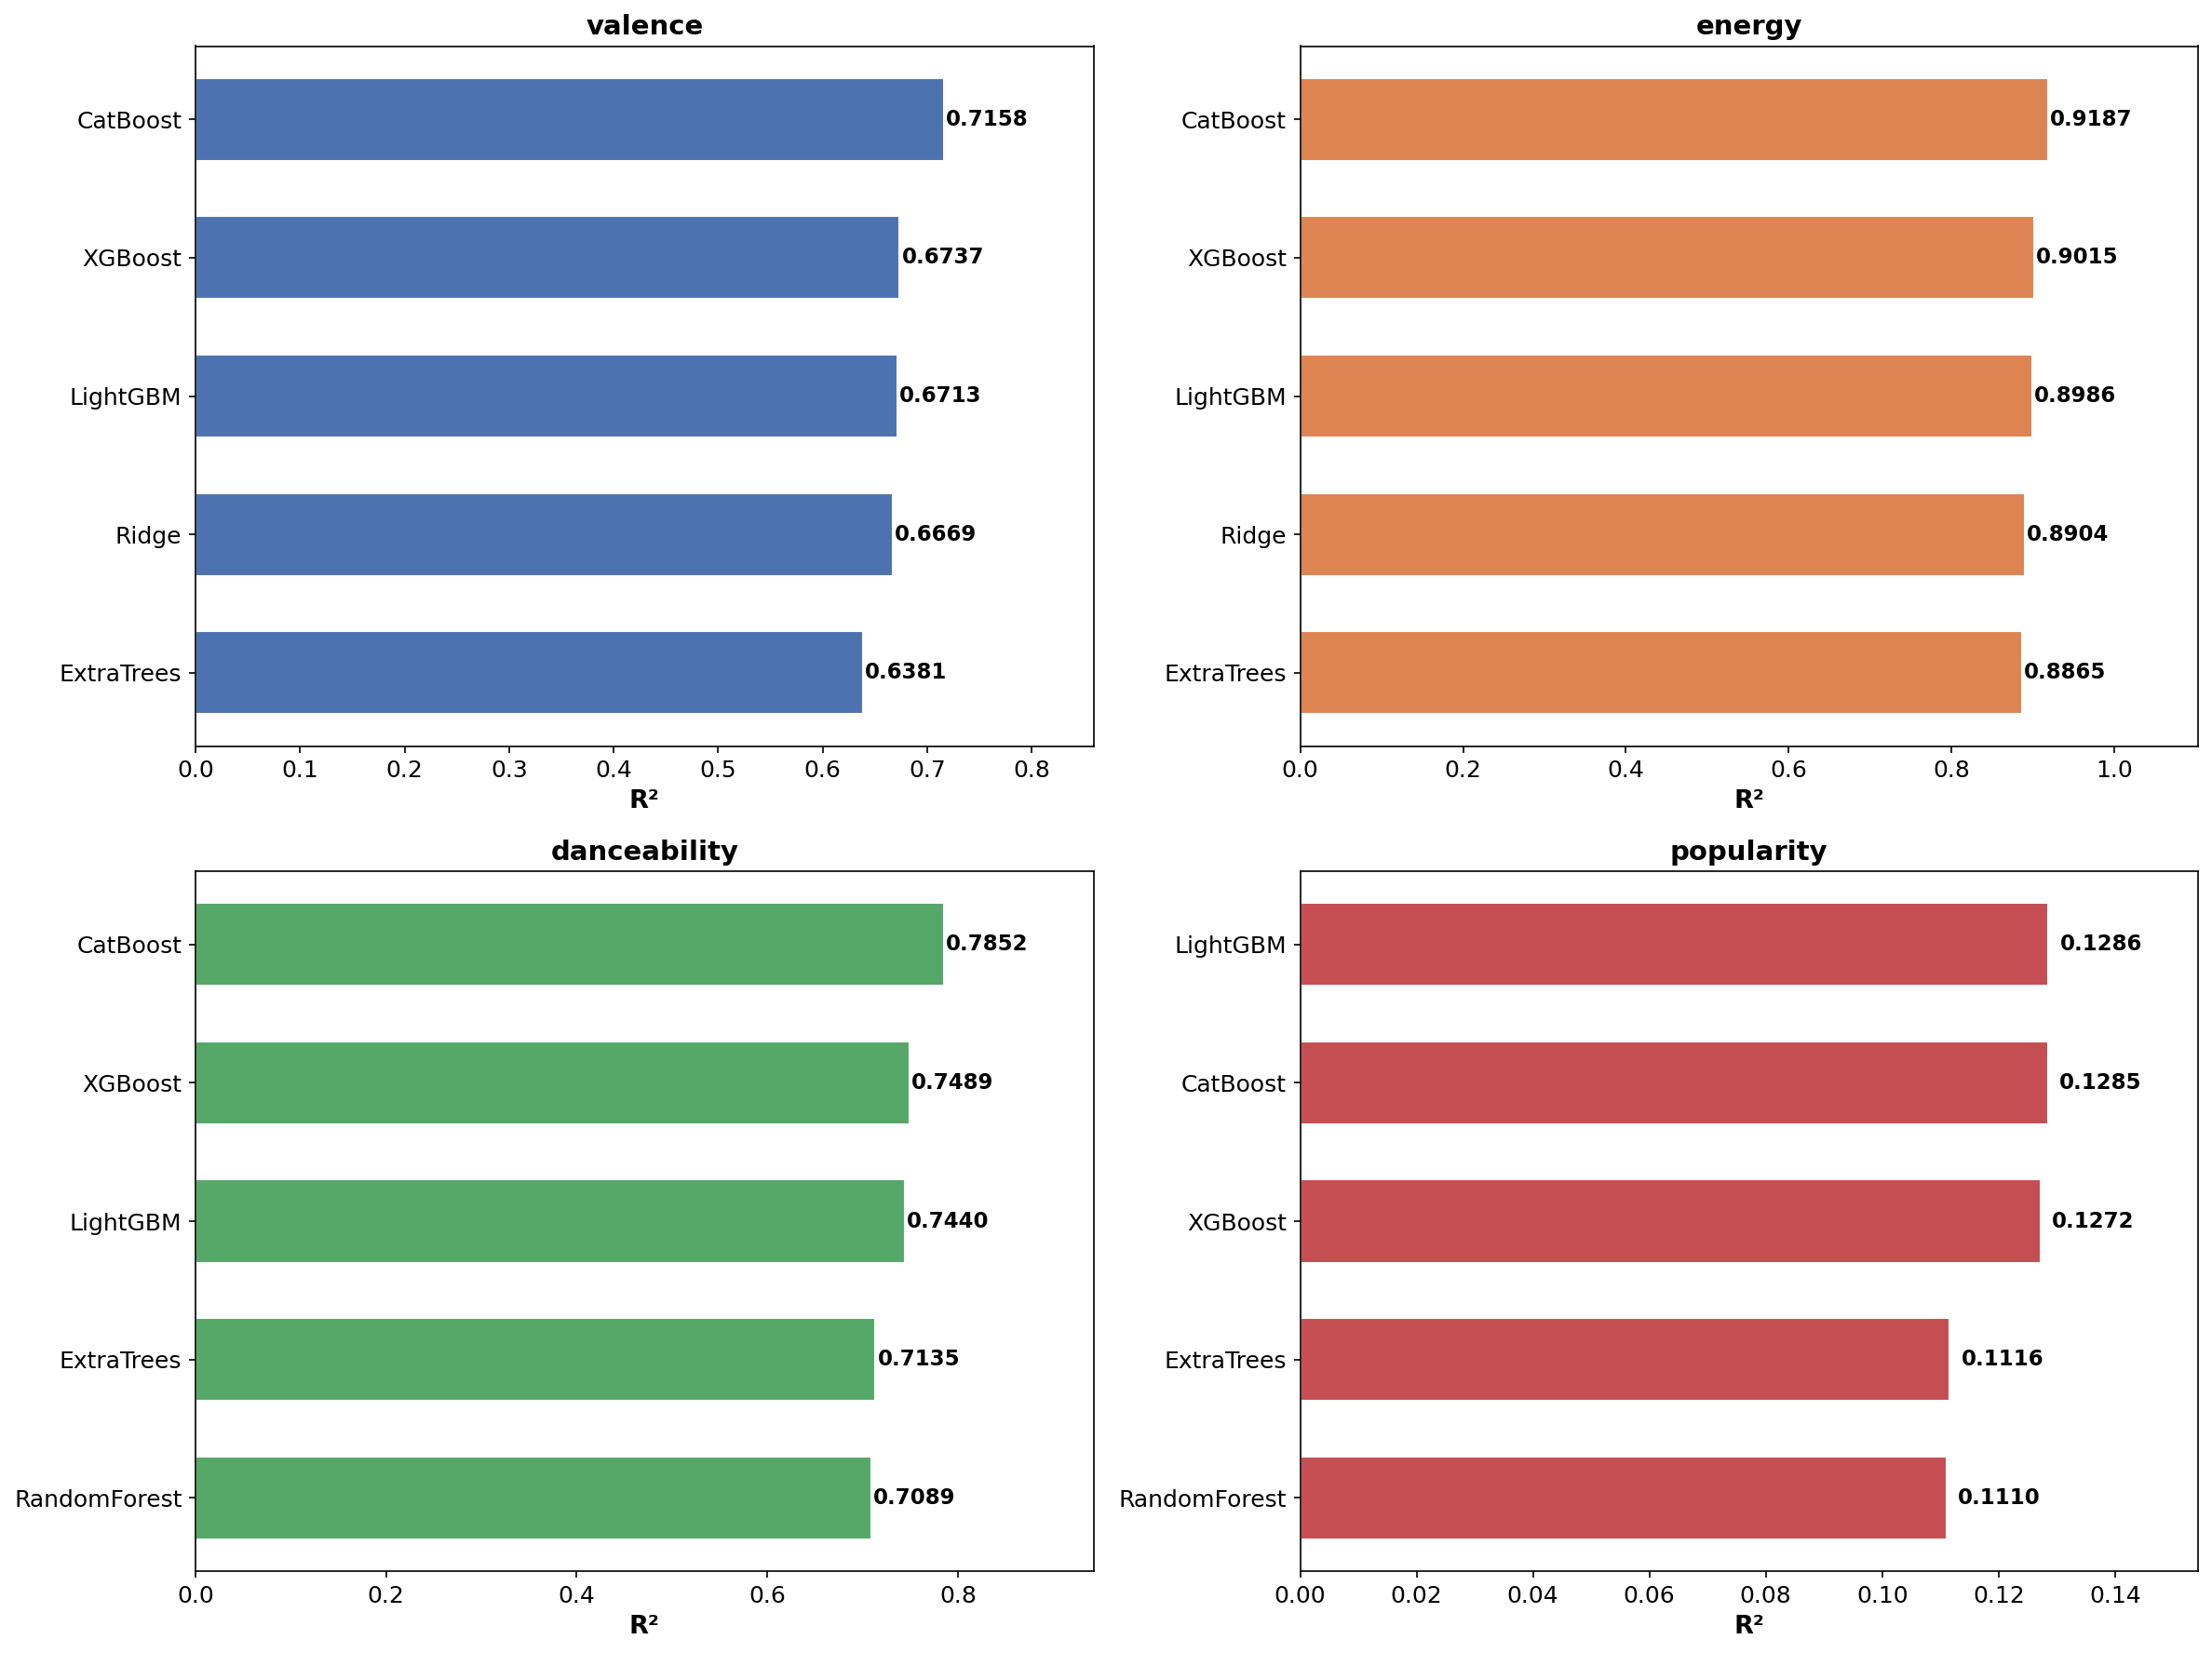

In [5]:
fig,axes=plt.subplots(2,2,figsize=(16,12))
for idx,t in enumerate(TARGETS):
    ax=axes[idx//2,idx%2]; sub=dft[dft['target']==t].sort_values('r2',ascending=False).head(5)
    bars=ax.barh(sub['model'],sub['r2'],color=TC[t],edgecolor='white',height=0.6)
    for b,v in zip(bars,sub['r2']): ax.text(b.get_width()+0.002,b.get_y()+b.get_height()/2,f'{v:.4f}',va='center',fontsize=11,fontweight='bold')
    ax.set_title(f'{t}',fontsize=14,fontweight='bold'); ax.set_xlabel('R²',fontsize=13,fontweight='bold')
    ax.set_xlim(0,max(sub['r2'])*1.2); ax.invert_yaxis()
plt.tight_layout(); fig.savefig(IMGS/'22_ml_top5.png'); plt.show()


## <span style="font-size:14pt; font-weight:bold;">4. CatBoost Default vs Tuned</span>


cd rows: 4, ct rows: 4
CatBoost: Default vs Tuned
--------------------------------------------------
  valence: 0.7158 -> 0.7220 (d=+0.0062)
  energy: 0.9187 -> 0.9212 (d=+0.0024)
  danceability: 0.7852 -> 0.7903 (d=+0.0051)
  popularity: 0.1285 -> 0.1316 (d=+0.0031)


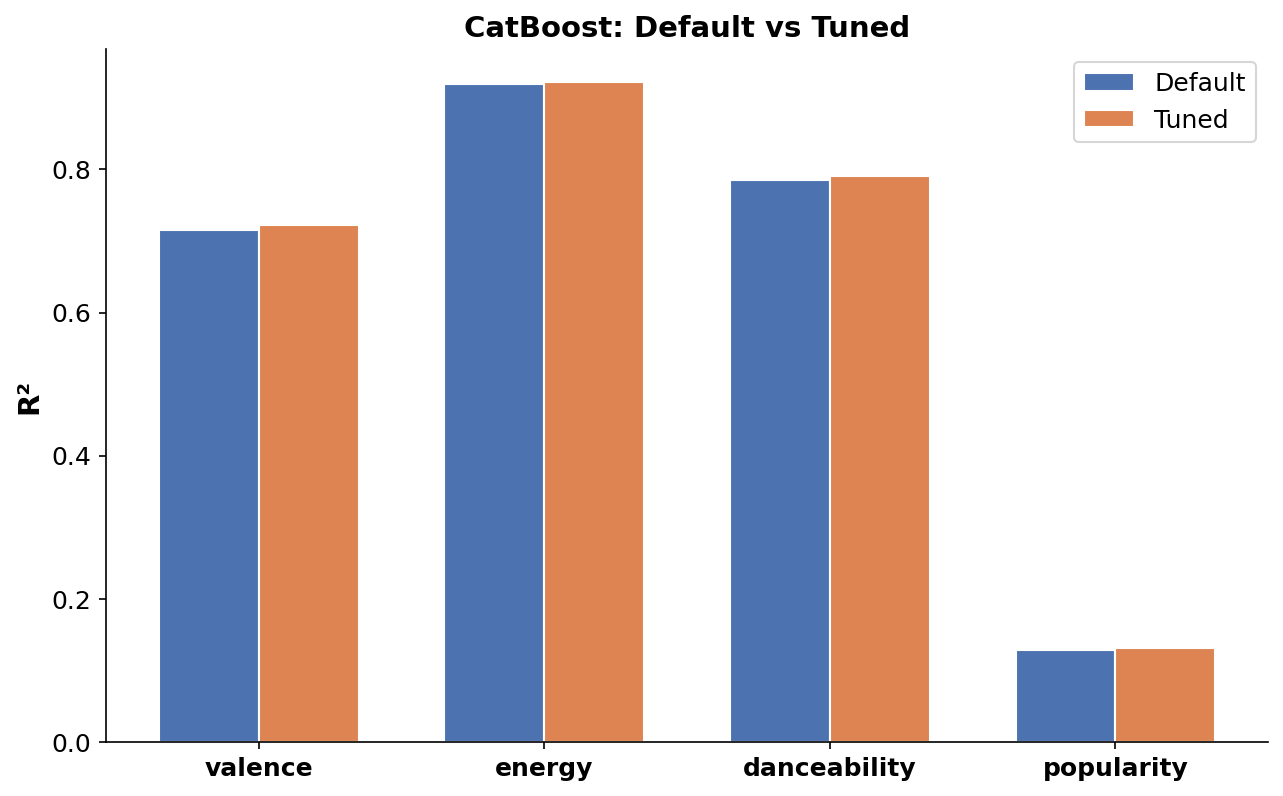

In [6]:
cd = dft[dft['model']=='CatBoost']
ct = ml[(ml['model']=='CatBoost_tuned') & (ml['tuning']=='tuned')]
print(f'cd rows: {len(cd)}, ct rows: {len(ct)}')

# Build target->r2 dicts directly (no merge needed)
cat_def = dict(zip(cd['target'], cd['r2']))
cat_tuned = dict(zip(ct['target'], ct['r2']))

print('CatBoost: Default vs Tuned'); print('-'*50)
dv, tv = [], []
for t in TARGETS:
    d = cat_tuned[t] - cat_def[t]
    print(f'  {t}: {cat_def[t]:.4f} -> {cat_tuned[t]:.4f} (d={d:+.4f})')
    dv.append(cat_def[t]); tv.append(cat_tuned[t])

fig,ax = plt.subplots(figsize=(10,6)); x = np.arange(len(TARGETS)); w = 0.35
ax.bar(x-w/2, dv, w, label='Default', color='#4C72B0', edgecolor='white')
ax.bar(x+w/2, tv, w, label='Tuned', color='#DD8452', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(TARGETS, fontsize=12, fontweight='bold')
ax.set_ylabel('R²', fontsize=14, fontweight='bold')
ax.set_title('CatBoost: Default vs Tuned', fontsize=14, fontweight='bold')
ax.legend(fontsize=12); sns.despine()
fig.savefig(IMGS/'22_catboost_d_vs_t.png'); plt.show()

## <span style="font-size:14pt; font-weight:bold;">5. Key Findings</span>


In [7]:
print('='*70); print('NOTEBOOK 22: KEY FINDINGS'); print('='*70)
for _,r in pr.iterrows(): print(f'  {r.name}: avg R² = {r["Avg"]:.4f}')
print(f'\nBest: {pr.index[0]}'); pr.round(6).to_csv(ANALYSIS/'22_ml_summary.csv',index=False)
print('Notebook 22 complete.')


NOTEBOOK 22: KEY FINDINGS
  CatBoost: avg R² = 0.6371
  XGBoost: avg R² = 0.6128
  LightGBM: avg R² = 0.6106
  Ridge: avg R² = 0.5912
  ExtraTrees: avg R² = 0.5874
  RandomForest: avg R² = 0.5821
  MLPRegressor: avg R² = 0.5568

Best: CatBoost
Notebook 22 complete.
